<a href="https://colab.research.google.com/github/kensley1972/Portifolio/blob/main/transferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este tutorial guiará você pelo processo de uso de aprendizado de transferência para aprender um classificador de imagem preciso a partir de um número relativamente pequeno de amostras de treinamento. Em termos gerais, o aprendizado de transferência se refere ao processo de alavancar o conhecimento aprendido em um modelo para o treinamento de outro modelo. Mais especificamente, o processo envolve pegar uma rede neural existente que foi previamente treinada para um bom desempenho em um conjunto de dados maior e usá-la como base para um novo modelo que alavanca a precisão dessa rede anterior para uma nova tarefa. Este método se tornou popular nos últimos anos para melhorar o desempenho de uma rede neural treinada em um pequeno conjunto de dados; a intuição é que o novo conjunto de dados pode ser muito pequeno para treinar para um bom desempenho por si só, mas sabemos que a maioria das redes neurais treinadas para aprender recursos de imagem geralmente aprendem recursos semelhantes de qualquer maneira, especialmente em camadas iniciais onde são mais genéricos (detectores de borda, blobs e assim por diante). O aprendizado de transferência foi amplamente habilitado pelo código aberto de modelos de última geração; para os modelos de melhor desempenho em tarefas de classificação de imagens (como do ILSVRC), é prática comum agora não apenas publicar a arquitetura, mas também liberar os pesos treinados do modelo. Isso permite que amadores usem esses principais classificadores de imagens para aumentar o desempenho de seus próprios modelos específicos de tarefas.

# Extração de recursos vs. ajuste fino

Em um extremo, o aprendizado de transferência pode envolver pegar a rede pré-treinada e congelar os pesos, e usar uma de suas camadas ocultas (geralmente a última) como um extrator de recursos, usando esses recursos como entrada para uma rede neural menor. No outro extremo, começamos com a rede pré-treinada, mas permitimos que alguns dos pesos (geralmente a última camada ou as últimas camadas) sejam modificados. Outro nome para esse procedimento é chamado de "ajuste fino" porque estamos ajustando ligeiramente os pesos da rede pré-treinada para a nova tarefa. Normalmente treinamos essa rede com uma taxa de aprendizado menor, pois esperamos que os recursos já sejam relativamente bons e não precisem ser alterados muito. Às vezes, fazemos algo intermediário: congelamos apenas as camadas iniciais/genéricas, mas ajustamos as camadas posteriores. Qual estratégia é melhor depende do tamanho do seu conjunto de dados, do número de classes e de quanto ele se assemelha ao conjunto de dados no qual o modelo anterior foi treinado (e, portanto, se ele pode se beneficiar dos mesmos extratores de recursos aprendidos).

#  Descrição do problema

Neste guia, passaremos pelo processo de carregamento de um classificador de imagens de última geração, de 1000 classes, o VGG16, que venceu o desafio
ImageNet em 2014, e o usaremos como um extrator de recursos fixos para treinar um classificador personalizado menor em nossas próprias imagens, embora com muitas poucas alterações de código, você também pode tentar fazer ajustes finos.
    - Primeiro, carregaremos o VGG16 e removeremos sua camada final, a camada de classificação softmax de 1000 classes específica para o ImageNet, e a substituiremos por uma nova camada de classificação para as classes que estamos treinando.
    - Em seguida, congelaremos todos os pesos na rede, exceto os novos que se conectam à nova camada de classificação, e então treinaremos a nova camada de classificação em nosso novo conjunto de dados.
    - Também compararemos esse método ao treinamento de uma pequena rede neural do zero no novo conjunto de dados e, como veremos, isso melhorará drasticamente nossa precisão. Faremos essa parte primeiro.
    - Vale a pena notar que essa estratégia escala bem para conjuntos de imagens onde você pode ter até mesmo apenas algumas centenas ou menos imagens. Seu desempenho será menor a partir de um pequeno número de amostras (dependendo das classes), como de costume, mas ainda impressionante considerando as restrições usuais.

Agradecimentos: Luiz Silva por ceder, gentimente, o dataset

In [ ]:
!git clone https://github.com/fenads/BairesDev-DIO.git

Cloning into 'BairesDev-DIO'...
remote: Enumerating objects: 225, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (222/222), done.
remote: Total 225 (delta 3), reused 219 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (225/225), 35.11 MiB | 36.65 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Bibliotecas
%matplotlib inline

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import keras
import cv2

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

from PIL import Image, UnidentifiedImageError
from PIL import Image

In [ ]:
root = '/content/BairesDev-DIO/Dataset-Pragas/'
exclude = ['BACKGROUND_Google', 'Motorbikes', 'airplanes', 'Faces_easy', 'Faces']
train_split, val_split = 0.7, 0.15

categories = [x[0] for x in os.walk(root) if x[0]][1:]
categories = [c for c in categories if c not in [os.path.join(root, e) for e in exclude]]

print(categories)

['/content/BairesDev-DIO/Dataset-Pragas/MoscaBranca', '/content/BairesDev-DIO/Dataset-Pragas/Bicudo']


In [ ]:
#Esta função é útil para pré-processar os dados em uma imagem e um vetor de entrada.
# Função auxiliar para carregar a imagem e retorná-la e o vetor de entrada
def get_image(path):
    try:
        with Image.open(path) as img:
            img.verify()  # Verifica se a imagem está corrompida
        img = image.load_img(path, target_size=(224, 224))  # Reabre a imagem
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        return img, x
    except (UnidentifiedImageError, OSError) as e:
        print(f"Erro ao carregar imagem {path}: {e}")
        return None, None

In [ ]:
# Verica se na base de dados há algum arquivo corrompido, inválido, ou outra extensão e os remove
invalid_files = []
for category in categories:
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg', '.png', '.jpeg']]

    for img_path in images:
        try:
            with Image.open(img_path) as img:
                img.verify()  # Tenta verificar se a imagem está corrompida
        except Exception as e:
            print(f"Imagem inválida: {img_path} ({e})")
            invalid_files.append(img_path)

# Remover arquivos corrompidos
for file in invalid_files:
    os.remove(file)
    print(f"Removido: {file}")

In [ ]:
# Carregue todas as imagens do diretorio
data = []
for c, category in enumerate(categories):
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
    for img_path in images:
        img, x = get_image(img_path)
        if img is not None and x is not None:  # Verifica se a imagem foi carregada corretamente e Ignora imagens corrompidas e danificadas
            data.append({'x': np.array(x[0]), 'y': c})

# count the number of classes
num_classes = len(categories)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
#Randomize a ordem dos dados.
random.shuffle(data)

In [ ]:
# create training / validation / test split (70%, 15%, 15%)
idx_val = int(train_split * len(data))
idx_test = int((train_split + val_split) * len(data))
train = data[:idx_val]
val = data[idx_val:idx_test]
test = data[idx_test:]

In [ ]:
# Dados separados para rótulos.
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]
print(y_test)

[0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1]


In [ ]:
# Pré-processe os dados como antes, certificando-se de que sejam float32 e normalizados entre 0 e 1.
# normalize data
x_train = x_train.astype('float32') / 255.
x_val = x_val.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# convert labels to one-hot vectors
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test.shape)

(32, 2)


In [ ]:
# Vamos fazer um resumo do que temos.
# summary
print("finished loading %d images from %d categories"%(len(data), num_classes))
print("train / validation / test split: %d, %d, %d"%(len(x_train), len(x_val), len(x_test)))
print("training data shape: ", x_train.shape)
print("training labels shape: ", y_train.shape)

finished loading 210 images from 2 categories
train / validation / test split: 147, 31, 32
training data shape:  (147, 224, 224, 3)
training labels shape:  (147, 2)


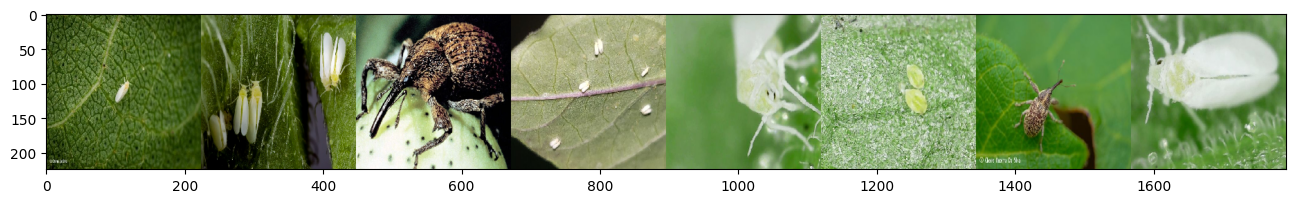

In [ ]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, Input

# Print input dimensions
print("Input dimensions: ", x_train.shape[1:])

# Define the model
model = Sequential([
    Input(shape=x_train.shape[1:]),  # Use Input layer instead of input_shape in Conv2D
    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.25),

    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(32, (3, 3)),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.25),

    Flatten(),
    Dense(256),
    Activation('relu'),

    Dropout(0.5),

    Dense(num_classes),
    Activation('softmax')
])

# Print model summary
model.summary()

Input dimensions:  (224, 224, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 222, 222, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 109, 109, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 52, 52, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,209,058 (4.61 MB)

 Trainable params: 1,209,058 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilar o modelo para usar a função de perda de entropia cruzada categórica e o otimizador adadelta
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_data=(x_val, y_val))

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4601 - loss: 0.7461 - val_accuracy: 0.5161 - val_loss: 0.6739
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5516 - loss: 0.6793 - val_accuracy: 0.5161 - val_loss: 0.6802
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4977 - loss: 0.7264 - val_accuracy: 0.5161 - val_loss: 0.6666
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4951 - loss: 0.6713 - val_accuracy: 0.5161 - val_loss: 0.6666
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5529 - loss: 0.6454 - val_accuracy: 0.6452 - val_loss: 0.6571
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6444 - loss: 0.6240 - val_accuracy: 0.6452 - val_loss: 0.6337
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7112 - loss: 0.5928 - val_accuracy: 0.6774 - val_loss: 0.6051
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.7437 - loss: 0.5617 - val_accuracy: 0.7419 - val_loss: 0.5683
Epoch 9/

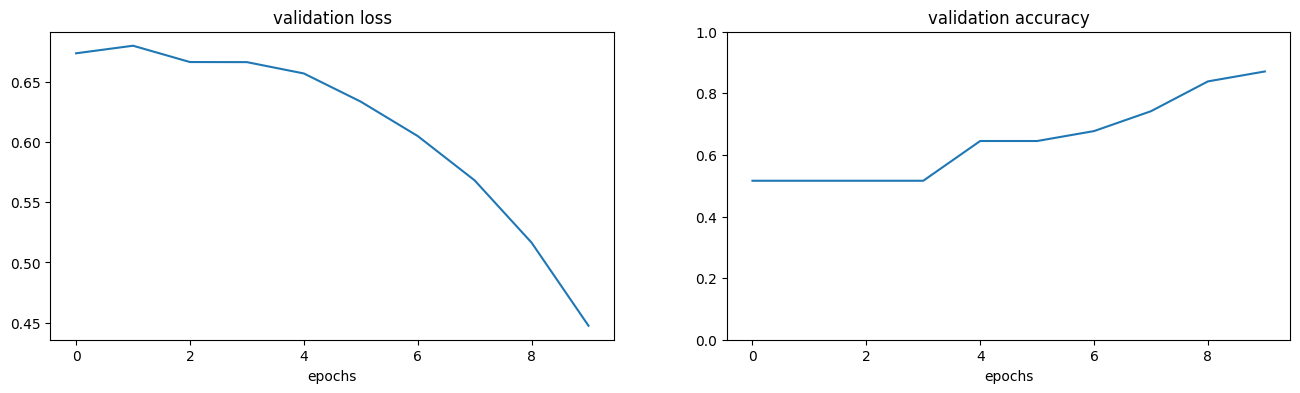

In [ ]:
# Vamos traçar a perda de validação e a precisão da validação ao longo do tempo.
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.4340578615665436
Test accuracy: 0.875


In [ ]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
new_classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = new_classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model_new = Model(inp, out)

In [ ]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

model_new.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_new.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 8,194 (32.01 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [ ]:
history2 = model_new.fit(x_train, y_train,
                         batch_size=128,
                         epochs=10,
                         validation_data=(x_val, y_val))

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 124s 34s/step - accuracy: 0.5373 - loss: 0.8294 - val_accuracy: 0.4839 - val_loss: 1.1739
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 155s 52s/step - accuracy: 0.5321 - loss: 1.0633 - val_accuracy: 0.5161 - val_loss: 0.9202
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 115s 36s/step - accuracy: 0.4977 - loss: 0.9498 - val_accuracy: 0.5161 - val_loss: 0.6841
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 113s 33s/step - accuracy: 0.4873 - loss: 0.7010 - val_accuracy: 0.6129 - val_loss: 0.5970
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 172s 52s/step - accuracy: 0.6346 - loss: 0.5836 - val_accuracy: 0.6452 - val_loss: 0.5371
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 176s 35s/step - accuracy: 0.7125 - loss: 0.5174 - val_accuracy: 0.8387 - val_loss: 0.4476
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 138s 33s/step - accuracy: 0.8443 - loss: 0.4402 - val_accuracy: 0.7097 - val_loss: 0.4854
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 145s 33s/step - accuracy: 0.8034 - loss: 0.4602 - val_accuracy: 0.8710 - val_loss:

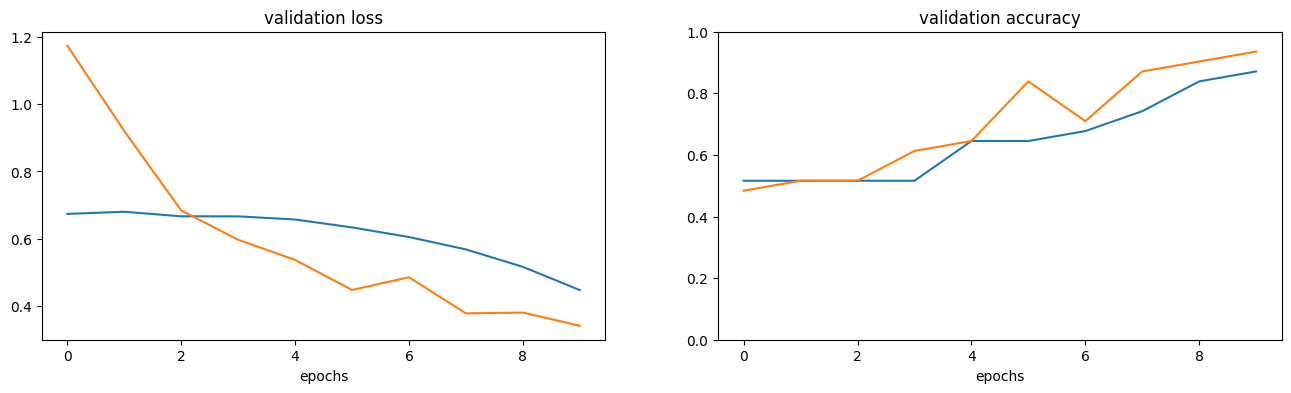

In [ ]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.plot(history2.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.plot(history2.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [ ]:
loss, accuracy = model_new.evaluate(x_test, y_test, verbose=0)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.3201943039894104
Test accuracy: 0.875


In [ ]:
# Para prever uma nova imagem, basta executar o código a seguir para obter as probabilidades de cada classe.
img, x = get_image('/content/drive/MyDrive/Colab Notebooks/Portifolio/projetoTransferLearning/PetImages/Dog/27.jpg')
print(type(x))  # Deve ser <class 'numpy.ndarray'>
print(x.shape)  # Deve ser (1, 224, 224, 3)

# Certificando de que get_image() está retornando x corretamente como um array de NumPy.
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)  # Converte a imagem para array NumPy
    x = np.expand_dims(x, axis=0)  # Adiciona dimensão batch (1, 224, 224, 3)
    x = x / 255.0  # Normaliza os valores para [0,1]
    return img, x  # Retorna a imagem original e o array formatado

probabilities = model_new.predict(x)  # Sem colchetes

# Certificando de que get_image() está retornando x corretamente como um array de NumPy.
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)  # Converte a imagem para array NumPy
    x = np.expand_dims(x, axis=0)  # Adiciona dimensão batch (1, 224, 224, 3)
    x = x / 255.0  # Normaliza os valores para [0,1]
    return img, x  # Retorna a imagem original e o array formatado

probabilities = model_new.predict(x)  # Sem colchetes


<class 'numpy.ndarray'>
(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
